In [26]:
# Nettoyage complet
print("Nettoyage...")
%reset -f
%whos

Nettoyage...
Interactive namespace is empty.


In [27]:
import numpy.random as rd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from sqlalchemy import text
import sqlalchemy
import gc
import pyodbc
from datetime import datetime
from pandas import NaT
import math
from scipy.stats import expon
import geopandas as gpd
import os
from shapely.geometry import Point
import contextily as ctx
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderUnavailable
import time
from scipy.stats import gaussian_kde
from sklearn.neighbors import KernelDensity
from joblib import Parallel, delayed
from matplotlib.colors import LogNorm
from matplotlib.colors import PowerNorm

In [28]:
# Connexion pyodbc à SQL Server

conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=172.16.11.33;"
    "DATABASE=LogiProDev;"
    "UID=quentin;"
    "PWD={Barbidur1;SQL}"
)

conn = pyodbc.connect(conn_str)
cursor = conn.cursor()

In [29]:
requete_lots_adresses = """
SELECT 
    tj.lot_id,
    l.lot_actif,
    a.adresse_id,
    a.adr_adresse,
    a.adr_adresse_cp,
    a.adr_adresse_ville,
    CAST(a.adr_plan_x AS FLOAT) AS adr_plan_x,
    CAST(a.adr_plan_y AS FLOAT) AS adr_plan_y,
    CAST(a.adr_geo_location AS VARCHAR(255)) AS adr_geo_location,
    a.code_insee_id
FROM dbo.tj_offre_lot tj
JOIN dbo.t_lot l ON tj.lot_id = l.lot_id
JOIN dbo.t_adresse a ON l.adresse_id = a.adresse_id
"""

requete_lots_infos_basiques = """
SELECT 
    tj.lot_id,
    l.lot_actif,
    l.lot_date_creation,
    l.lot_date_archive,
    l.lot_surface,
    l.lot_batiment,
    l.etage_id,
    l.adresse_id
FROM dbo.tj_offre_lot tj
JOIN dbo.t_lot l ON tj.lot_id = l.lot_id
"""

In [30]:
lots_adresses = pd.read_sql_query(requete_lots_adresses, conn)
print(lots_adresses.columns)

lots_infos_basiques = pd.read_sql_query(requete_lots_infos_basiques, conn)
print(lots_infos_basiques.columns)

C:\Users\quent\AppData\Local\Temp\ipykernel_22944\97871670.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  lots_adresses = pd.read_sql_query(requete_lots_adresses, conn)


Index(['lot_id', 'lot_actif', 'adresse_id', 'adr_adresse', 'adr_adresse_cp',
       'adr_adresse_ville', 'adr_plan_x', 'adr_plan_y', 'adr_geo_location',
       'code_insee_id'],
      dtype='object')


C:\Users\quent\AppData\Local\Temp\ipykernel_22944\97871670.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  lots_infos_basiques = pd.read_sql_query(requete_lots_infos_basiques, conn)


Index(['lot_id', 'lot_actif', 'lot_date_creation', 'lot_date_archive',
       'lot_surface', 'lot_batiment', 'etage_id', 'adresse_id'],
      dtype='object')


In [31]:
conn.commit()
cursor.close()
conn.close()

In [32]:
gdf_offres = gpd.GeoDataFrame(lots_adresses, geometry=gpd.points_from_xy(lots_adresses.adr_plan_x, lots_adresses.adr_plan_y), crs="EPSG:4326")

# Reprojeter en Web Mercator 
gdf_offres = gdf_offres.to_crs(epsg=3857)

In [33]:
del lots_adresses
gc.collect()

0

In [34]:
# Supprimer la colonne si elle existe déjà
if 'lot_actif' in gdf_offres.columns :
    gdf_offres.drop(columns='lot_actif', inplace=True)
if 'lot_actif_x' in gdf_offres.columns :
    gdf_offres.drop(columns='lot_actif_x', inplace=True)
if 'lot_actif_y' in gdf_offres.columns :
    gdf_offres.drop(columns='lot_actif_y', inplace=True)

In [35]:
lots_actifs = lots_infos_basiques.groupby('lot_id', as_index=False)['lot_actif'].max()
gdf_offres = gdf_offres.merge(lots_actifs, on='lot_id', how='left')

# Filtrage : uniquement les points actifs
gdf_offres = gdf_offres[gdf_offres['lot_actif'] == 1]

gdf_offres = gdf_offres.to_crs(epsg=3857)

In [36]:
del lots_actifs
del lots_infos_basiques 
gc.collect()

0

In [37]:
# On ne garde que ce qui est en France
gdf_offres = gdf_offres.cx[-560000:1200000, 5000000:6700000]

# Vérifier les min/max
print(gdf_offres['adr_plan_x'].min(), gdf_offres['adr_plan_x'].max())
print(gdf_offres['adr_plan_y'].min(), gdf_offres['adr_plan_y'].max())

# Vérifier les valeurs manquantes
print(gdf_offres[['adr_plan_x', 'adr_plan_y']].isnull().sum())

-4.77380330000005 9.448236465454102
41.39147524875518 51.2312752
adr_plan_x    0
adr_plan_y    0
dtype: int64


In [38]:
# Charger les régions métropolitaines
gdf_regions = gpd.read_file("https://france-geojson.gregoiredavid.fr/repo/regions.geojson")
codes_metropole = ['11', '24', '27', '28', '32', '44', '52', '53', '75', '76', '84', '93', '94']
gdf_regions = gdf_regions[gdf_regions['code'].isin(codes_metropole)].copy()

# Assurer la même projection
gdf_regions = gdf_regions.to_crs(epsg=3857)
gdf_offres = gdf_offres.to_crs(epsg=3857)

# Liste pour stocker les résultats
region_counts = []

# Boucler sur chaque région
for idx, region in gdf_regions.iterrows():
    region_name = region['nom']
    region_geom = region.geometry
    count = gdf_offres.geometry.within(region_geom).sum()
    region_counts.append({"region": region_name, "nombre_lots": count})

# Créer un DataFrame
df_lots_par_region = pd.DataFrame(region_counts).sort_values(by="region").reset_index(drop=True)

print(df_lots_par_region)

                        region  nombre_lots
0         Auvergne-Rhône-Alpes       307731
1      Bourgogne-Franche-Comté         2419
2                     Bretagne         9504
3          Centre-Val de Loire        12980
4                        Corse           12
5                    Grand Est        29719
6              Hauts-de-France       106048
7                    Normandie        15147
8           Nouvelle-Aquitaine        73716
9                    Occitanie        56570
10            Pays de la Loire        27570
11  Provence-Alpes-Côte d'Azur        58371
12               Île-de-France      1596172


In [41]:
# Charger les données
kde_france = pd.read_parquet("kde_france_metropole.parquet", engine="fastparquet")

# Boucle manuelle pour multiplier par le nombre de lots de chaque région
for i, row in df_lots_par_region.iterrows():
    region = row["region"]
    nb_lots = row["nombre_lots"]
    
    mask = kde_france["region"] == region
    kde_france.loc[mask, "density"] = kde_france.loc[mask, "density"] * nb_lots

kde_france["density"] = (kde_france["density"] / (df_lots_par_region["nombre_lots"].sum()))*1000000

print(kde_france["density"].sum())

0.9999932210725011


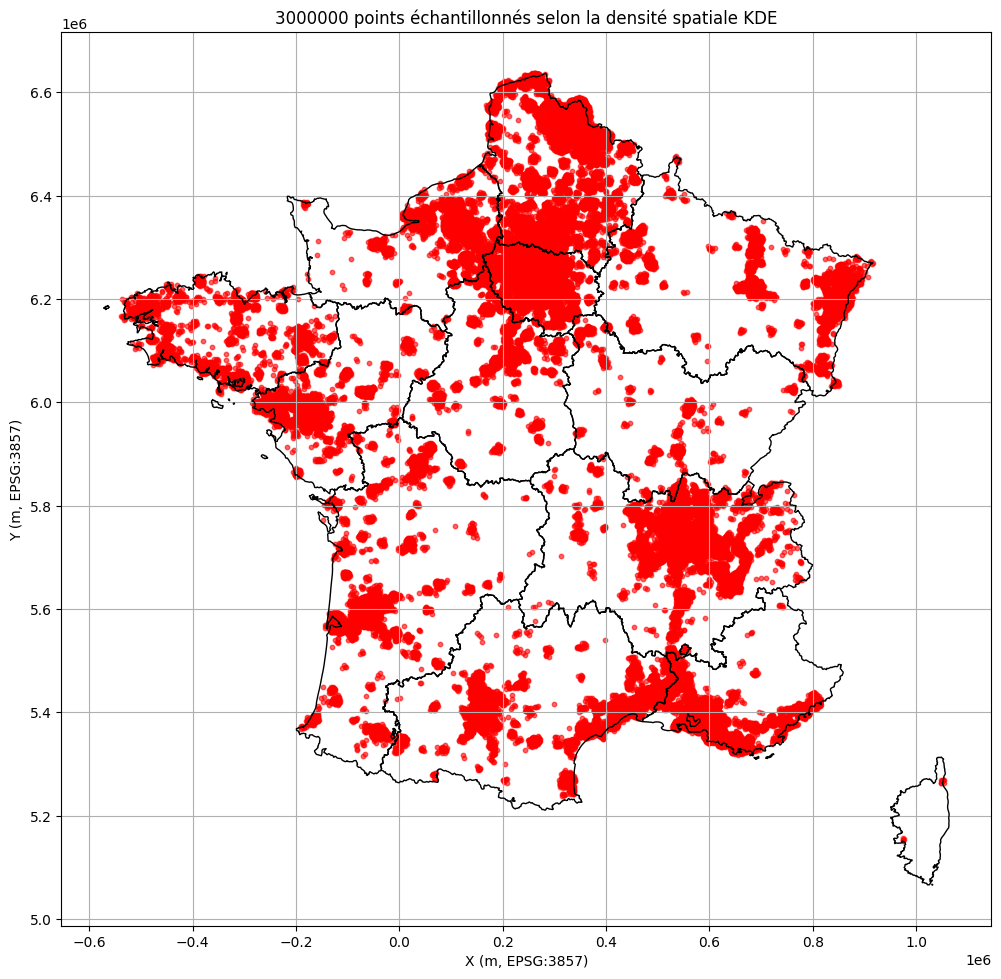

In [ ]:
n_points = 3000000

# Normalisation défensive (on n'était pas exactement à 1)
kde_france["density"] = kde_france["density"] / kde_france["density"].sum()

# Tirage d'indices pondérés par la densité
indices = np.random.choice(kde_france.index, size=n_points, p=kde_france["density"].values)

# Récupération des coordonnées correspondantes
sampled = kde_france.loc[indices, ["x", "y"]].copy()
sampled["geometry"] = [Point(xy) for xy in zip(sampled["x"], sampled["y"])]
gdf_points = gpd.GeoDataFrame(sampled, geometry="geometry", crs="EPSG:3857")

gdf_regions = gpd.read_file("https://france-geojson.gregoiredavid.fr/repo/regions.geojson")
codes_metropole = ['11', '24', '27', '28', '32', '44', '52', '53', '75', '76', '84', '93', '94']
gdf_regions = gdf_regions[gdf_regions["code"].isin(codes_metropole)].to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 12))
gdf_regions.boundary.plot(ax=ax, color="black", linewidth=1)
gdf_points.plot(ax=ax, color="red", markersize=10, alpha=0.6)
ax.set_title(f"{n_points} points échantillonnés selon la densité spatiale KDE")
ax.set_xlabel("X (m, EPSG:3857)")
ax.set_ylabel("Y (m, EPSG:3857)")
plt.grid(True)
plt.show()